# Can displacement heterogeneity alone cause InSAR closure phase?

**Yes, after multilooking; static SAR texture alone is insufficient.** Fixed scattering
coefficients and an unequal mixture of displacement histories are enough. A symmetric
Gaussian velocity distribution instead loses coherence while its population phase
still closes. This distinction can reconcile apparently different simulation results. Section 6 shows
what phase linking returns when fed such a mixture, and Section 7 contrasts a
transient moisture-like nuisance with persistent motion to show where each biases the
estimators, and what closure phase can and cannot tell you about it.

This executable companion to the five-page explainer uses original toy experiments,
not a reproduction of the paper's real data or polygon simulations. It is motivated by
Biessel, Lohman & Zwieback (2026), *Displacement Heterogeneity and Associated InSAR
Closure Phases in a Permafrost Landscape*, [doi:10.1109/TGRS.2026.3729078](https://doi.org/10.1109/TGRS.2026.3729078),
especially Sections II, IV and VI. Mathematical derivations below make the assumptions
explicit. Nothing here establishes which model Zheng and Fattahi privately tested.

**Run:** Python 3.10+, `numpy`, `matplotlib`, and a Jupyter kernel. Optional sliders
also need `ipywidgets`. All static figures are saved in notebook outputs; no SAR data,
network access, Dolphin installation, or GDAL is needed. Set `ENABLE_WIDGETS = True`
in the last cell for live controls. Lengths are millimetres; times are days.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display as show_widget

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "savefig.facecolor": "white",
    }
)
BLUE, ORANGE, GREEN = "#17658c", "#b54e1a", "#238477"


def mixture_covariance(displacement_mm, wavelength_mm=56.0, weights=None):
    """Compute population coherence for fixed powers and LOS histories."""
    d = np.asarray(displacement_mm, dtype=float)
    w = np.ones(d.shape[1]) if weights is None else np.asarray(weights, dtype=float)
    w = w / w.sum()
    z = np.exp(-1j * 4 * np.pi * d / wavelength_mm)
    return (z * w) @ z.conj().T


def closure(C):
    """Compute wrapped closure of the first three acquisitions, in radians."""
    return np.angle(C[0, 1] * C[1, 2] * C[2, 0])


def sample_coherence(slc):
    """Average interferograms across columns (looks), then normalize powers."""
    C = slc @ slc.conj().T / slc.shape[1]
    power = np.sqrt(np.diag(C).real)
    return C / (power[:, None] * power[None, :])


def z_two(x, p=0.2):
    """Coherence after removing a common stationary-component phase."""
    return 1 - p + p * np.exp(1j * x)

## 1. The minimum electromagnetics: fields add before intensities

A monochromatic field propagates with a range-dependent complex phase. For a
monostatic radar the outward and return paths give $2k_0R=4\pi R/\lambda$.
After focusing and removing known geometry, use the convention

$$s_i(\ell)=\sum_m h_{\ell m}a_m\exp[-iqd_{im}],\qquad q=4\pi/\lambda.$$

Here $d_{im}>0$ increases slant range; $a_m$ is a **complex field scattering
coefficient** containing static reflectivity and initial range phase; $h_{\ell m}$
is a fixed imaging response. These are linear, single-scattering, fixed-geometry
approximations, not a full Maxwell solver. All $a_m$ and $h_{\ell m}$ remain fixed
in time. No dielectric change or time-varying scattering coefficient is used.
Multiple additive contributors do not require multiple-bounce scattering.

A changing complex permittivity can separately change propagation phase, attenuation
and scattering weights inside soil or vegetation. Holding it fixed does not prevent
geometric range changes from rotating different contributors differently.

**Three different operations matter.** (1) Coherently add unresolved scatterer fields
inside each SLC pixel. (2) Multiply SLC pairs. (3) Average those complex pair products
across a multilook window. Averaging the SLCs into a single scalar and then forming
all interferograms is not operation (3).

At **one observed SLC pixel**, even one containing many changing scatterers,

$$(s_0s_1^*)(s_1s_2^*)(s_2s_0^*)=|s_0s_1s_2|^2.$$

Its phase is zero whenever the product is nonzero. This identity also holds with
changing permittivity. The closure mechanism appears in the averaged covariance:

$$C_{ij}=\langle s_i s_j^*\rangle,\qquad
\Xi_{012}=\arg(C_{01}C_{12}C_{20}).$$

There is no corresponding cancellation between three separately averaged pair
products. Normalizing $C$ to a coherence matrix changes magnitudes, not phases.
Under independent random initial phases, unresolved cross terms vanish in the
ensemble, leaving

$$C_{ij}=\sum_m w_m e^{-iq(d_{im}-d_{jm})},\quad w_m\geq0,\quad\sum_m w_m=1.$$

The same expression holds exactly for resolved constant-amplitude components
pooled with fixed weights. The $w_m$ are **power** fractions: an area fraction $f$
with power density ratio $r$ has $p=fr/(1-f+fr)$. Equal dielectric properties and
equal power per area already suffice; a small fast-moving area gives unequal $p$.
The matrix is a sum of positive-semidefinite outer products, so the example is a
physically admissible covariance, not arbitrary inconsistent pair phases.

## 2. A minimal, noise-free counterexample

Take two populations: stationary and moving away at $v$, with moving power fraction
$p=0.2$. Choose acquisition times $0,\Delta t,2\Delta t$ so that
$x=qv\Delta t=1$ radian. Then

$$z(x)=0.8+0.2e^{ix},\qquad
\Xi=\arg\{z(1)^2z(2)^*\}\neq0.$$

For $\lambda=56$ mm and $\Delta t=12$ days, $v=0.37136$ mm/day **LOS**.
Every constituent interferogram closes before averaging. No random noise is needed.

LOS rate of moving component: 0.371362 mm/day
Short-pair phase: 0.183254 rad
Long-pair phase:  0.248477 rad
Closure: 0.118031 rad = 6.763 deg
Minimum pair coherence: 0.7395
Power-weighted mean rate: 0.074272 mm/day
Short-pair apparent rate: 0.068054 mm/day
Long-pair apparent rate: 0.046137 mm/day


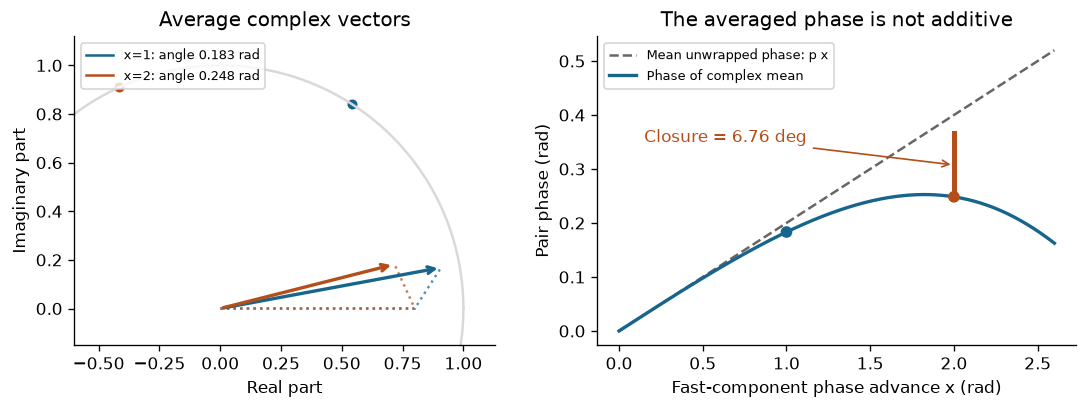

In [2]:
wavelength, dt, p = 56.0, 12.0, 0.2
v = wavelength / (4 * np.pi * dt)
times = np.array([0.0, dt, 2 * dt])
d = np.outer(times, [0.0, v])
C = mixture_covariance(d, wavelength, [1 - p, p])
phi_short = np.angle(C[0, 1])
phi_long = np.angle(C[0, 2])
print(f"LOS rate of moving component: {v:.6f} mm/day")
print(f"Short-pair phase: {phi_short:.6f} rad")
print(f"Long-pair phase:  {phi_long:.6f} rad")
print(f"Closure: {closure(C):.6f} rad = {np.degrees(closure(C)):.3f} deg")
print(f"Minimum pair coherence: {np.abs(C[np.triu_indices(3, 1)]).min():.4f}")
print(f"Power-weighted mean rate: {p * v:.6f} mm/day")
print(
    f"Short-pair apparent rate: {phi_short * wavelength / (4 * np.pi * dt):.6f} mm/day"
)
print(
    "Long-pair apparent rate: "
    f"{phi_long * wavelength / (4 * np.pi * 2 * dt):.6f} mm/day"
)
np.testing.assert_allclose(C, C.conj().T, atol=1e-14)
assert np.linalg.eigvalsh(C).min() > -1e-12
assert closure(C) > 0.1

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3), layout="constrained")
a = np.linspace(0, 2 * np.pi, 400)
axes[0].plot(np.cos(a), np.sin(a), color="0.85")
for x, color in [(1, BLUE), (2, ORANGE)]:
    z = z_two(x)
    axes[0].plot([0, 0.8, z.real], [0, 0, z.imag], ":", color=color, alpha=0.7)
    axes[0].annotate(
        "",
        (z.real, z.imag),
        (0, 0),
        arrowprops={"arrowstyle": "->", "color": color, "lw": 2},
    )
    axes[0].scatter([np.cos(x)], [np.sin(x)], color=color, s=25)
    axes[0].plot([], [], color=color, label=f"x={x}: angle {np.angle(z):.3f} rad")
axes[0].set(
    xlim=(-0.6, 1.13),
    ylim=(-0.15, 1.12),
    aspect="equal",
    xlabel="Real part",
    ylabel="Imaginary part",
    title="Average complex vectors",
)
axes[0].legend(fontsize=8, loc="upper left")
x = np.linspace(0, 2.6, 400)
axes[1].plot(x, p * x, "--", color="0.4", label="Mean unwrapped phase: p x")
axes[1].plot(x, np.angle(z_two(x)), color=BLUE, lw=2, label="Phase of complex mean")
axes[1].scatter([1, 2], [phi_short, phi_long], color=[BLUE, ORANGE], zorder=3)
axes[1].plot([2, 2], [phi_long, 2 * phi_short], color=ORANGE, lw=3)
axes[1].annotate(
    f"Closure = {np.degrees(closure(C)):.2f} deg",
    (2, (phi_long + 2 * phi_short) / 2),
    (0.15, 0.35),
    arrowprops={"arrowstyle": "->", "color": ORANGE},
    color=ORANGE,
)
axes[1].set(
    xlabel="Fast-component phase advance x (rad)",
    ylabel="Pair phase (rad)",
    title="The averaged phase is not additive",
)
axes[1].legend(fontsize=8, loc="upper left")
plt.show()

## 3. Why a simple heterogeneity model may close

For time-independent velocity $v$ drawn from a fixed power-weighted distribution,
the forward-time coherence is its characteristic function
$\chi(u)=E[e^{iuv}]$, with $u=q\Delta t$. For small phase spread, the cumulant expansion is

$$\arg\chi(u)=\mu u-\kappa_3u^3/6+O(u^5),$$
$$\Xi\simeq\frac{\kappa_3}{2}q^3\Delta t_{01}\Delta t_{12}
(\Delta t_{01}+\Delta t_{12}).$$

The mean velocity cancels. Variance produces leading-order coherence loss;
the third cumulant (third central moment) produces leading-order continuous
misclosure. For two equal spacings, the last expression is
$\kappa_3(q\Delta t)^3$. For a two-population mixture,
$\kappa_3=p(1-p)(1-2p)v^3$. Zero third cumulant alone does **not** guarantee exact
closure: higher odd cumulants can matter. The cubic law is local, not valid near
coherence nulls or wrapping. At fixed LOS velocity statistics it predicts
$\lambda^{-3}$ scaling for small phase spread; real C/L-band comparisons can also
change scattering weights and footprints.

| Model with fixed weights | Population result |
|---|---|
| Arbitrary static reflectivity + common motion history | Closes: one common phase factors out |
| $C_{ij}=r_{ij}e^{i(\theta_i-\theta_j)}$, real $r_{ij}>0$ | Closes even with decorrelation |
| Gaussian velocities, or any jointly Gaussian displacement history | $\chi(u)=e^{i\mu u-\sigma^2u^2/2}$: closes exactly |
| Symmetric velocity distribution | Centered $\chi$ is real: closure is 0 or $\pi$, where defined |
| Unequal mixture of different velocities | Generally nonlinear pair phase and nonzero closure |
| Independently redraw all scatterer phases each date | Population off-diagonals vanish; phase is undefined |

Two generalizations matter when reading the paper. First, the Gaussian row is not
limited to constant velocities. For any jointly Gaussian displacement history,
$E[e^{-iq(d_i-d_j)}]=\exp[-iq(\mu_i-\mu_j)-q^2\,\mathrm{Var}(d_i-d_j)/2]$, whose phase is
linear in the mean history, so a Gaussian random walk, Gaussian seasonal amplitudes,
or any other Gaussian temporal structure closes exactly. Skewed, non-Gaussian
statistics are required. Second, the weights are power fractions, so backscatter
that correlates with motion can skew an area-symmetric velocity distribution: three
populations at $-v,0,+v$ with area fractions $1/4,1/2,1/4$ close exactly, but if the
fastest-subsiding population is also the brightest (wetter troughs, for instance),
the power-weighted distribution is skewed and closure appears. Both are checked
numerically below.

The symmetric case deserves care: an equal-weight two-speed mixture has
$z(x)=e^{ix/2}\cos(x/2)$. It closes while all centered pair coherences are positive,
but can give a $\pi$ closure when their signs differ. At a zero coherence, assigning
`angle(0)=0` is a numerical convention, not a meaningful measurement.

Possible reasons a trial model found zero include Gaussian/symmetric velocity
statistics, applying one motion history to the whole window, averaging unwrapped
phases, averaging SLCs before all pair formation, or phase-linking before measuring
closure. These are diagnostic possibilities, **not claims about the unpublished
Zheng/Fattahi experiment**. Their published moisture model is a distinct sufficient
mechanism ([author summary](https://yujiezheng.me/publication/soilmoisture/)).

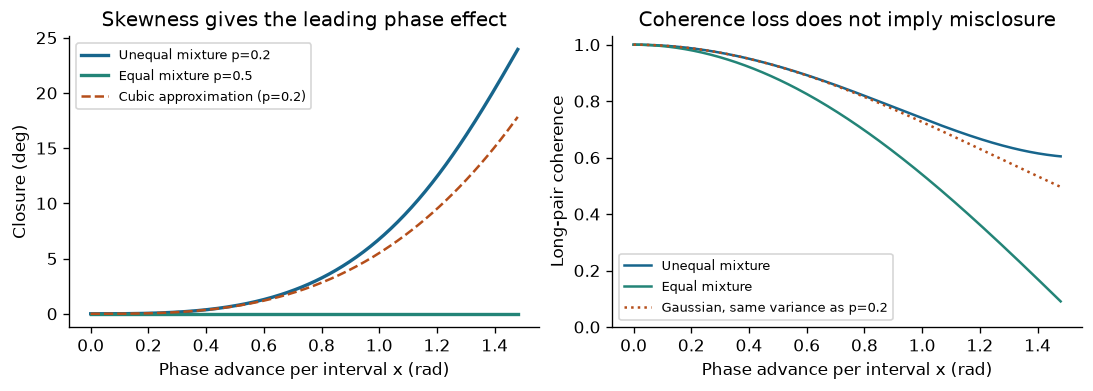

Homogeneous, Gaussian, symmetric, pi-closure and common-motion checks passed.
Area-symmetric, brightness-weighted closure: -13.59 deg


In [3]:
x = np.linspace(0, 1.48, 250)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.15), layout="constrained")
for p_case, label, color in [
    (0.2, "Unequal mixture p=0.2", BLUE),
    (0.5, "Equal mixture p=0.5", GREEN),
]:
    clo = np.angle(z_two(x, p_case) ** 2 * z_two(2 * x, p_case).conj())
    axes[0].plot(x, np.degrees(clo), label=label, color=color, lw=2)
axes[0].plot(
    x,
    np.degrees(0.2 * 0.8 * 0.6 * x**3),
    "--",
    color=ORANGE,
    label="Cubic approximation (p=0.2)",
)
axes[0].set(
    xlabel="Phase advance per interval x (rad)",
    ylabel="Closure (deg)",
    title="Skewness gives the leading phase effect",
)
axes[0].legend(fontsize=8)
axes[1].plot(x, abs(z_two(2 * x, 0.2)), color=BLUE, label="Unequal mixture")
axes[1].plot(x, abs(z_two(2 * x, 0.5)), color=GREEN, label="Equal mixture")
axes[1].plot(
    x,
    np.exp(-0.5 * 0.16 * (2 * x) ** 2),
    ":",
    color=ORANGE,
    label="Gaussian, same variance as p=0.2",
)
axes[1].set(
    xlabel="Phase advance per interval x (rad)",
    ylabel="Long-pair coherence",
    title="Coherence loss does not imply misclosure",
    ylim=(0, 1.03),
)
axes[1].legend(fontsize=8)
plt.show()

for weights in ([1, 0], [0, 1], [0.5, 0.5]):
    np.testing.assert_allclose(
        closure(mixture_covariance(d, wavelength, weights)), 0, atol=1e-12
    )
C_pi = mixture_covariance(2 * d, wavelength, [0.5, 0.5])
np.testing.assert_allclose(abs(closure(C_pi)), np.pi, atol=1e-12)
C_common = mixture_covariance(d + np.array([0, 7, -3])[:, None], wavelength, [0.8, 0.2])
np.testing.assert_allclose(closure(C_common), closure(C), atol=1e-12)
u = np.array([0.0, 1.0, 2.0])
du = u[None, :] - u[:, None]
C_gauss = np.exp(1j * 0.2 * du - 0.5 * 0.16 * du**2)
np.testing.assert_allclose(closure(C_gauss), 0, atol=1e-12)
# Jointly Gaussian displacement with arbitrary temporal covariance closes.
rng_gauss = np.random.default_rng(1)
mixing = rng_gauss.normal(size=(5, 5))
d_gauss = np.array([0, 3, 7, 8, 12.0])[:, None] + 2.0 * mixing @ rng_gauss.normal(
    size=(5, 400_000)
)
C_gauss_sim = sample_coherence(np.exp(-1j * 4 * np.pi * d_gauss / wavelength))
for start in range(3):
    triplet = C_gauss_sim[start : start + 3, start : start + 3]
    np.testing.assert_allclose(closure(triplet), 0, atol=0.01)
# Brightness correlated with motion skews an area-symmetric distribution.
d_three = np.outer([0.0, 1.0, 2.0], [-1.0, 0.0, 1.0]) * wavelength / (4 * np.pi)
area = np.array([0.25, 0.5, 0.25])
np.testing.assert_allclose(closure(mixture_covariance(d_three, wavelength, area)), 0, atol=1e-12)
bright = closure(mixture_covariance(d_three, wavelength, area * [0.5, 1.0, 2.0]))
assert abs(bright) > 0.2
print("Homogeneous, Gaussian, symmetric, pi-closure and common-motion checks passed.")
print(f"Area-symmetric, brightness-weighted closure: {np.degrees(bright):.2f} deg")

## 4. Unresolved scatterers: add their fields, then multilook

Now each observed look contains both motion populations:
$s_i(\ell)=\sqrt{1-p}\,a_\ell+\sqrt{p}\,b_\ell e^{-iqvt_i}$.
The independent $a_\ell,b_\ell$ are unit-power circular complex Gaussian fields,
representing unresolved groups of rough-surface scatterers. Draw them once and
**reuse them at every acquisition**. Their coefficients do not evolve; only the
geometric phases do. Individual pixel intensities may still change through interference.

This coherent field sum has exactly the covariance derived above in the ensemble.
The simulation below uses 256 independent repetitions at each look count. Lines
show circular ensemble means of closure; bands show the 10th-90th percentiles of
wrapped deviations around that circular mean (not confidence intervals). For one
look every repetition closes; for many looks the unequal mixture tends toward a
nonzero value. No temporal decorrelation or dielectric variability has been added.
A finite symmetric realization can misclose even when its population closes.

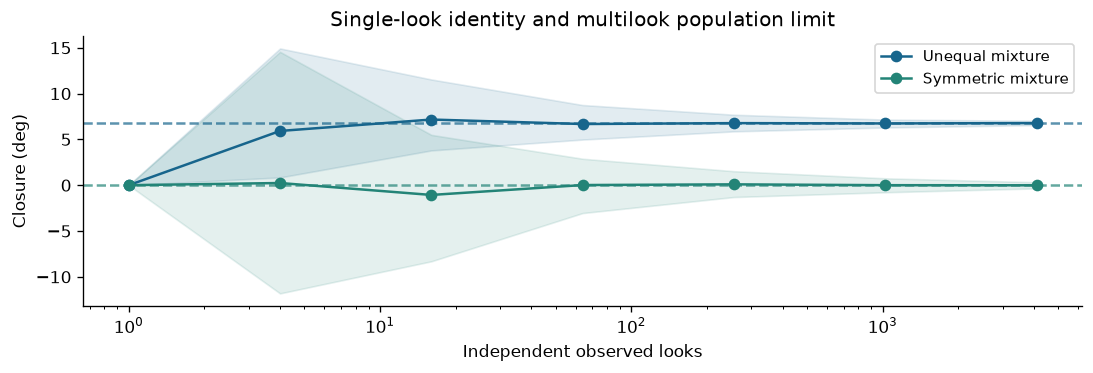

4096-look circular ensemble means (deg): {'0.2': 6.776, '0.5': -0.012}


In [4]:
rng = np.random.default_rng(20260908)
looks_grid = np.array([1, 4, 16, 64, 256, 1024, 4096])
fig, ax = plt.subplots(figsize=(9, 3.0), layout="constrained")
convergence = {}
for frac, color, label in [
    (0.2, BLUE, "Unequal mixture"),
    (0.5, GREEN, "Symmetric mixture"),
]:
    population = mixture_covariance(d, wavelength, [1 - frac, frac])
    phase = np.exp(-1j * 4 * np.pi * d / wavelength)
    means, lower, upper = [], [], []
    for nlooks in looks_grid:
        a = (
            rng.normal(size=(256, 2, nlooks)) + 1j * rng.normal(size=(256, 2, nlooks))
        ) / np.sqrt(2)
        slc = np.einsum("tm,rml->rtl", phase * np.sqrt([1 - frac, frac]), a)
        covariance = np.einsum("rtl,rul->rtu", slc, slc.conj()) / nlooks
        values = np.angle(
            covariance[:, 0, 1] * covariance[:, 1, 2] * covariance[:, 2, 0]
        )
        mean = np.angle(np.mean(np.exp(1j * values)))
        delta = np.angle(np.exp(1j * (values - mean)))
        low, high = np.quantile(delta, [0.1, 0.9])
        means.append(mean)
        lower.append(mean + low)
        upper.append(mean + high)
        if nlooks == 1:
            np.testing.assert_allclose(values, 0, atol=1e-12)
    ax.plot(looks_grid, np.degrees(means), "o-", color=color, label=label)
    ax.fill_between(
        looks_grid, np.degrees(lower), np.degrees(upper), color=color, alpha=0.12
    )
    ax.axhline(np.degrees(closure(population)), color=color, ls="--", alpha=0.7)
    convergence[str(frac)] = float(means[-1])
    assert abs(np.angle(np.exp(1j * (means[-1] - closure(population))))) < 0.01
ax.set(
    xscale="log",
    xlabel="Independent observed looks",
    ylabel="Closure (deg)",
    title="Single-look identity and multilook population limit",
)
ax.legend(fontsize=9)
plt.show()
print(
    "4096-look circular ensemble means (deg):",
    {k: round(float(np.degrees(v)), 3) for k, v in convergence.items()},
)

## 5. Knobs: power fraction, differential velocity, wavelength and baseline

The plots below show the **exact population** result for times $0,\Delta t,2\Delta t$.
Changing $p$ is changing the moving **power fraction**, not necessarily area fraction.
Changing wavelength holds the toy scattering weights and LOS displacement fixed.
The gray heatmap region masks any triplet with minimum pair coherence below 0.05;
it is a visualization cutoff, not a validated quality threshold. The dashed $p=0.5$
line includes the $\pi$ branch as baselines grow. Wrapped closure need not increase
monotonically with baseline; coherence can revive in this discrete two-speed model.

For vertical settlement use $v_{LOS}=v_{vertical}\cos\theta$ when the geometry
makes settlement increase range. Reversing the interferogram convention reverses
closure signs. All comparisons here use $C_{ij}=E[s_i s_j^*]$, as in Dolphin.

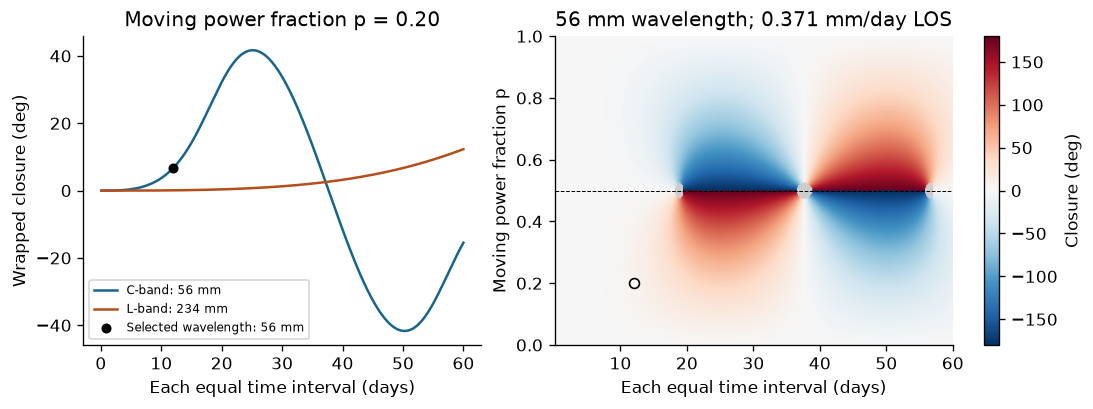

Selected closure: 6.763 deg; min pair coherence: 0.739


In [5]:
def explore(p=0.2, velocity_mm_day=0.3713615, dt_days=12.0, wavelength_mm=56.0):
    """Plot fixed-power two-speed motion; values are population quantities."""
    xs = 4 * np.pi * velocity_mm_day * dt_days / wavelength_mm
    cc = np.angle(z_two(xs, p) ** 2 * z_two(2 * xs, p).conj())
    minimum = min(abs(z_two(xs, p)), abs(z_two(2 * xs, p)))
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), layout="constrained")
    baseline = np.linspace(0.1, 60, 360)
    for wave, color, label in [
        (56, BLUE, "C-band: 56 mm"),
        (234, ORANGE, "L-band: 234 mm"),
    ]:
        xx = 4 * np.pi * velocity_mm_day * baseline / wave
        result = np.angle(z_two(xx, p) ** 2 * z_two(2 * xx, p).conj())
        valid = np.minimum(abs(z_two(xx, p)), abs(z_two(2 * xx, p))) >= 0.05
        result[~valid] = np.nan
        # Break lines across the wrapped phase boundary.
        result[np.r_[False, abs(np.diff(result)) > np.pi]] = np.nan
        axes[0].plot(baseline, np.degrees(result), color=color, label=label)
    if minimum >= 0.05:
        axes[0].scatter(
            [dt_days],
            [np.degrees(cc)],
            color="black",
            s=25,
            label=f"Selected wavelength: {wavelength_mm:g} mm",
            zorder=3,
        )
    axes[0].set(
        xlabel="Each equal time interval (days)",
        ylabel="Wrapped closure (deg)",
        title=f"Moving power fraction p = {p:.2f}",
    )
    axes[0].legend(fontsize=7)
    pp = np.linspace(0, 1, 251)[:, None]
    xx = 4 * np.pi * velocity_mm_day * baseline[None, :] / wavelength_mm
    z1, z2 = z_two(xx, pp), z_two(2 * xx, pp)
    angles = np.degrees(np.angle(z1 * z1 * z2.conj()))
    angles[np.minimum(abs(z1), abs(z2)) < 0.05] = np.nan
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#cccccc")
    im = axes[1].imshow(
        angles,
        origin="lower",
        aspect="auto",
        extent=(0.1, 60, 0, 1),
        cmap=cmap,
        vmin=-180,
        vmax=180,
    )
    axes[1].axhline(0.5, color="black", lw=0.6, ls="--")
    axes[1].scatter([dt_days], [p], s=35, color="white", edgecolor="black")
    axes[1].set(
        xlabel="Each equal time interval (days)",
        ylabel="Moving power fraction p",
        title=f"{wavelength_mm:g} mm wavelength; {velocity_mm_day:.3f} mm/day LOS",
    )
    fig.colorbar(im, ax=axes[1], label="Closure (deg)")
    plt.show()
    value = f"{np.degrees(cc):.3f} deg" if minimum >= 0.05 else "masked: low coherence"
    print(f"Selected closure: {value}; min pair coherence: {minimum:.3f}")


explore()

## 6. What phase linking reports for a mixture

Dolphin's estimators assume the rank-one model $C_{ij}=\gamma_{ij}e^{i(\theta_i-\theta_j)}$
with real $\gamma_{ij}$. The mixture violates it: $C$ has rank two and no single phase
history reproduces its pair phases. Feeding it in anyway asks a practical question:
**which motion comes out?**

Take eight dates at 12-day spacing (the paper's Sentinel-1 sampling) with $p=0.2$, and
multiply every off-diagonal by a constant 0.8 to stand in for additive noise. A real
positive factor leaves all closure phases unchanged (Section 3) but keeps $|C|$
invertible. Three estimators are applied to the population $C$:

- **Nearest-neighbor chain**: cumulative sum of the 12-day pair phases, as in the
  paper's Sentinel-1 processing.
- **EVD**: phase of the dominant eigenvector (Dolphin's `use_evd=True`).
- **EMI**: smallest eigenvector of $|C|^{-1}\circ C$ (Dolphin's default).

The linked phase $\theta_k$ is an SLC phase, so $\theta_k-\theta_0=-q(d_k-d_0)$; the chain
negates the pair angles to use the same convention. Markers repeat the estimators on
100-look sample covariances, using the circular mean over 300 realizations.


x = 1 rad per interval, p = 0.2: LOS displacement after 84 days
  Power-weighted mean        6.239 mm
  Nearest-neighbor chain     5.717 mm
  EVD                        0.191 mm
  EMI                        0.197 mm


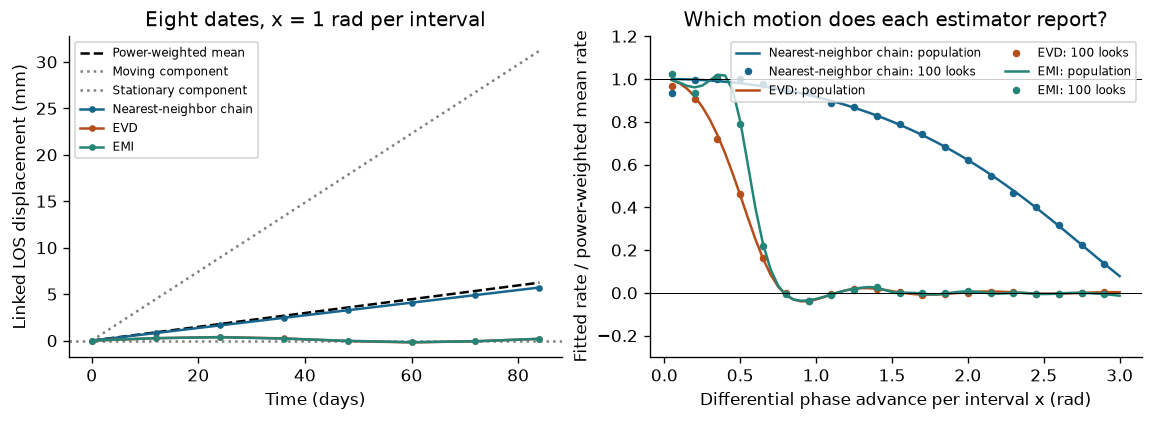

In [6]:
def evd_phase(C):
    """Return the linked SLC phase from the dominant eigenvector (Dolphin `use_evd`)."""
    _, v = np.linalg.eigh(C)
    return np.angle(v[..., :, -1] * v[..., :1, -1].conj())


def emi_phase(C):
    """Return the linked SLC phase from EMI: smallest eigenvector of |C|^-1 * C."""
    _, v = np.linalg.eigh(np.linalg.inv(np.abs(C)) * C)
    return np.angle(v[..., :, 0] * v[..., :1, 0].conj())


def chain_phase(C):
    """Return the linked SLC phase from cumulative nearest-neighbor pair phases."""
    pairs = np.angle(np.diagonal(C, offset=1, axis1=-2, axis2=-1))
    zero = np.zeros(C.shape[:-2] + (1,))
    return np.concatenate([zero, -np.cumsum(pairs, axis=-1)], axis=-1)


def linked_displacement(theta):
    """Convert theta_k - theta_0 = -q (d_k - d_0) to LOS displacement in mm."""
    return -np.unwrap(theta, axis=-1) * wavelength / (4 * np.pi)


ESTIMATORS = {
    "Nearest-neighbor chain": (chain_phase, BLUE),
    "EVD": (evd_phase, ORANGE),
    "EMI": (emi_phase, GREEN),
}
q = 4 * np.pi / wavelength
stack_times = np.arange(8) * dt
coherence_factor = 0.8  # additive white noise: a real factor, so it closes
rng_link = np.random.default_rng(6)


def population_stack(x):
    """Return the eight-date mixture coherence for phase advance x per interval."""
    v_x = x / (q * dt)
    d_x = np.outer(stack_times, [0.0, v_x])
    C = mixture_covariance(d_x, wavelength, [1 - p, p]) * coherence_factor
    np.fill_diagonal(C, 1.0)
    return C, v_x


def sample_stacks(x, nlooks=100, nreal=300):
    """Draw fixed component fields plus white noise; return sample coherences."""
    v_x = x / (q * dt)
    d_x = np.outer(stack_times, [0.0, v_x])
    fields = rng_link.normal(size=(nreal, 2, nlooks)) + 1j * rng_link.normal(
        size=(nreal, 2, nlooks)
    )
    noise = rng_link.normal(size=(nreal, 8, nlooks)) + 1j * rng_link.normal(
        size=(nreal, 8, nlooks)
    )
    components = np.exp(-1j * q * d_x) * np.sqrt([1 - p, p])
    slc = np.einsum("tm,rml->rtl", components, fields / np.sqrt(2))
    slc += noise * np.sqrt((1 / coherence_factor - 1) / 2)
    C = np.einsum("rtl,rul->rtu", slc, slc.conj()) / nlooks
    power = np.sqrt(np.einsum("rtt->rt", C).real)
    return C / (power[:, :, None] * power[:, None, :])


fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), layout="constrained")
C_one, v_one = population_stack(1.0)
axes[0].plot(stack_times, p * v_one * stack_times, "k--", label="Power-weighted mean")
axes[0].plot(stack_times, v_one * stack_times, ":", color="0.5", label="Moving component")
axes[0].axhline(0, ls=":", color="0.5", label="Stationary component")
print(f"x = 1 rad per interval, p = {p}: LOS displacement after {stack_times[-1]:.0f} days")
print(f"  {'Power-weighted mean':24s} {p * v_one * stack_times[-1]:7.3f} mm")
for name, (estimator, color) in ESTIMATORS.items():
    disp = linked_displacement(estimator(C_one))
    axes[0].plot(stack_times, disp, "o-", ms=3, color=color, label=name)
    print(f"  {name:24s} {disp[-1]:7.3f} mm")
axes[0].set(
    xlabel="Time (days)",
    ylabel="Linked LOS displacement (mm)",
    title="Eight dates, x = 1 rad per interval",
)
axes[0].legend(fontsize=7)

x_grid = np.linspace(0.05, 3.0, 60)
for name, (estimator, color) in ESTIMATORS.items():
    ratios = []
    for x in x_grid:
        C_x, v_x = population_stack(x)
        rate = np.polyfit(stack_times, linked_displacement(estimator(C_x)), 1)[0]
        ratios.append(rate / (p * v_x))
    axes[1].plot(x_grid, ratios, color=color, label=f"{name}: population")
    sampled = []
    for x in x_grid[::3]:
        theta = np.angle(np.mean(np.exp(1j * estimator(sample_stacks(x))), axis=0))
        rate = np.polyfit(stack_times, linked_displacement(theta), 1)[0]
        sampled.append(rate / (p * x / (q * dt)))
    axes[1].plot(x_grid[::3], sampled, "o", ms=3.5, color=color, label=f"{name}: 100 looks")
    if name != "Nearest-neighbor chain":
        assert abs(ratios[0] - 1) < 0.02 and abs(ratios[-1]) < 0.02
axes[1].axhline(1, color="k", lw=0.6)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(
    xlabel="Differential phase advance per interval x (rad)",
    ylabel="Fitted rate / power-weighted mean rate",
    ylim=(-0.3, 1.2),
    title="Which motion does each estimator report?",
)
axes[1].legend(fontsize=7, ncol=2)
plt.show()

Below $x\approx0.4$ rad per interval, every estimator returns the power-weighted mean
rate. Once the moving population accumulates about one cycle over the 84-day span, EVD
and EMI switch to the **dominant power component**: the 80% stationary population, so
they report no motion at all. The nearest-neighbor chain degrades gradually, because its
step is $\arg z(x)$ rather than $px$: 0.92 of the mean rate at $x=1$, and falling.
Finite-look estimates follow the population curves.

Nothing here involves a dielectric change. The "short baselines see more motion"
signature that motivates short-baseline bias corrections arises from displacement
heterogeneity alone. Differential settlement of 0.25 to 0.5 mm/day within ice-wedge
polygons, projected to a 35 degree incidence, gives $x\approx0.5$ to 1.1 rad per 12-day
C-band interval, so this regime is realistic. For Dolphin users: closure phase on the
sample covariance flags the mismatch; when it is present, phase linking is not an
unbiased spatial average but a vote won by the brightest coherent population; and the
choice of estimator or `baseline_lag` changes which population wins. None of these
outputs is the mean settlement of the window.


EMI's whitening by $|C|^{-1}$ is derived for the rank-one model, where the smallest
eigenvalue of $|C|^{-1}\circ C$ equals one exactly (Fiedler's inequality). Under the mixture
that eigenvalue departs from one and, as the stack grows, EMI's solution stops meaning
anything while EVD keeps degrading gracefully toward the dominant population. The eigenvalue
itself is therefore a free mismatch indicator. Sample noise and the `beta` regularization
soften this in practice, but not the underlying model error.


In [7]:
gamma_test = np.abs(population_stack(0.7)[0])
np.testing.assert_allclose(np.linalg.eigvalsh(np.linalg.inv(gamma_test) * gamma_test)[0], 1.0, atol=1e-9)
for n_dates in (8, 20, 50):
    d_n = np.outer(np.arange(n_dates) * dt, [0.0, 0.3 / (q * dt)])
    C_n = mixture_covariance(d_n, wavelength, [1 - p, p]) * coherence_factor
    np.fill_diagonal(C_n, 1.0)
    smallest = np.linalg.eigvalsh(np.linalg.inv(np.abs(C_n)) * C_n)[0]
    print(
        f"N={n_dates:3d}: EVD final {linked_displacement(evd_phase(C_n))[-1]:8.2f} mm,"
        f" EMI final {linked_displacement(emi_phase(C_n))[-1]:9.2f} mm,"
        f" smallest eigenvalue of |C|^-1 * C = {smallest:8.2f}"
        f" (stationary 0, mean motion {0.2 * 0.3 * (n_dates - 1) * wavelength / (4 * np.pi):.2f})"
    )

N=  8: EVD final     1.47 mm, EMI final      1.89 mm, smallest eigenvalue of |C|^-1 * C =     1.00 (stationary 0, mean motion 1.87)
N= 20: EVD final     0.04 mm, EMI final      0.07 mm, smallest eigenvalue of |C|^-1 * C =     1.09 (stationary 0, mean motion 5.08)
N= 50: EVD final     0.32 mm, EMI final    139.43 mm, smallest eigenvalue of |C|^-1 * C =   -17.71 (stationary 0, mean motion 13.10)


## 7. Transient nuisance versus persistent motion: where the bias lives

Any pair-phase matrix splits into a gradient part, $\theta_i-\theta_j$, and a cycle part.
Closure phases measure only the cycle part; displacement is pure gradient. A nuisance
process contributes to both, and its gradient part is indistinguishable from displacement
in a single covariance matrix. So closure phase can **detect** a process that violates the
rank-one model, but no estimator can remove the resulting bias from the covariance alone;
a physical model or outside information is required. What an estimator *can* choose is
which pairs it trusts, and the two processes in this notebook reward opposite choices.

- **Transient nuisance** (soil or vegetation moisture: fast wetting, slow drying). The pair
  phase depends on the difference of two moisture states through an odd, saturating
  function. Pairs longer than the moisture correlation time compare independent states and
  have zero mean phase error; the bias lives in short pairs. Long-baseline estimators are
  unbiased if, and only if, coherent long pairs exist.
- **Persistent differential motion** (Section 6). Long pairs are the most misleading: they
  see the dominant population. Short pairs track the power-weighted mean.

Zwieback and Biessel (2024) built the time-timescale framework for exactly this question.
Their *small-steps* basis is the cumulative nearest closure, their *two-hops* basis is the
closure of triplets $(i,\,i+k,\,i+2k)$ used below, and their model scenarios already predict
that event-driven soil moisture biases the nearest-neighbor estimate while unresolved
differential motion biases the all-interferogram estimate. What this section adds is finite
looks, a Dolphin-style sequential estimator, and the coherence criterion above.

The simulation uses a depth mixture with fixed scattering weights, AR(1) temporal
decorrelation with time $\tau_c$, additive white noise, and **zero true motion**. Moisture
anomalies arrive at random times and decay exponentially. "Rare" means one event per 20
acquisitions with a 36-day decay; "frequent" means one per 3 acquisitions with a 24-day
decay, the irrigated-turf regime. Five estimators run on 200-look sample covariances: the
nearest-neighbor chain, coherence-weighted least squares over lags 1 to 2 (a nearest-2
SBAS network) or over all lags, EVD on the whole stack, and a Dolphin-style sequential EVD
with ministacks of 10 that links through compressed SLCs referenced to date 0.


Apparent rate with zero true motion (mm/yr), mean ± sd over realizations
                                      Rare wetting, long coherence   Rare wetting, short coherence  Frequent wetting, long coheren  Frequent wetting, short cohere
Nearest-neighbor chain                            4.59 ±  1.76                    4.30 ±  2.22                    0.90 ±  1.21                    1.08 ±  1.44    
Weighted LS, lags 1-2                             2.79 ±  1.15                    2.82 ±  1.83                    0.37 ±  1.08                    0.64 ±  1.29    
Weighted LS, all lags                            -0.22 ±  0.78                   -0.11 ±  1.15                   -0.07 ±  0.99                    0.03 ±  1.17    
EVD, whole stack                                 -0.21 ±  0.76                    0.85 ±  7.59                   -0.06 ±  0.96                    1.04 ±  6.85    
Sequential EVD, ministacks of 10                 -0.21 ±  0.77                   -1.90 ±  9.45                  

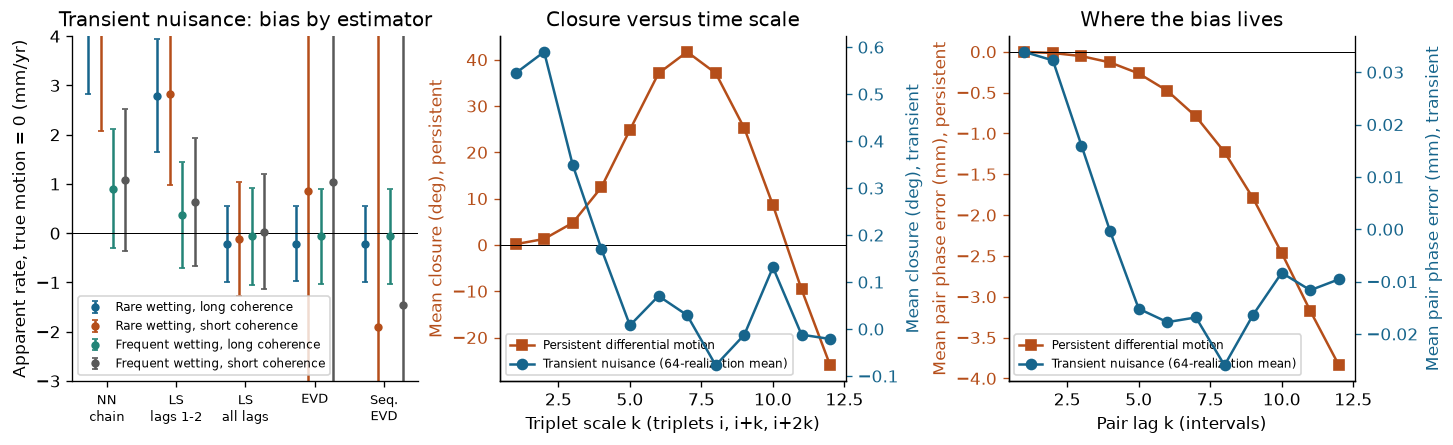

In [8]:
rng_bias = np.random.default_rng(7)
N_DATES = 60
times_bias = np.arange(N_DATES) * dt
MM_PER_RAD = wavelength / (4 * np.pi)
LAYERS = np.arange(30)
DEPTH_WEIGHTS = np.exp(-LAYERS / 8.0)
DEPTH_WEIGHTS /= DEPTH_WEIGHTS.sum()
PHASE_PER_LAYER = 0.25  # rad per unit moisture anomaly per layer


def moisture_history(spacing, tau_m, amp, spinup=40):
    """Asymmetric anomalies: instantaneous wetting, exponential drying with time tau_m."""
    n_events = max(1, (N_DATES + spinup) // spacing)
    events = rng_bias.choice(np.arange(-spinup, N_DATES), size=n_events, replace=False)
    m = np.zeros(N_DATES)
    for e in events:
        m += amp * np.exp(-(times_bias - e * dt) / tau_m) * (times_bias >= e * dt)
    return m


def nuisance_population(m, tau_c, noise_factor=0.9):
    """Population coherence: depth mixture times AR(1) decorrelation times white noise."""
    dm = m[:, None] - m[None, :]
    mix = np.einsum("n,ijn->ij", DEPTH_WEIGHTS, np.exp(1j * PHASE_PER_LAYER * dm[..., None] * LAYERS))
    rho = np.exp(-np.abs(times_bias[:, None] - times_bias[None, :]) / tau_c)
    C = rho * noise_factor * mix
    np.fill_diagonal(C, 1.0)
    return C


def nuisance_slcs(m, tau_c, nlooks, noise_factor=0.9):
    """One realization of SLC looks: fixed depth weights, AR(1) layer fields, white noise."""
    rho = np.exp(-dt / tau_c)
    fields = rng_bias.normal(size=(len(LAYERS), nlooks)) + 1j * rng_bias.normal(size=(len(LAYERS), nlooks))
    fields /= np.sqrt(2)
    slc = np.zeros((N_DATES, nlooks), complex)
    sigma = np.sqrt((1 / noise_factor - 1) / 2)
    for k in range(N_DATES):
        if k:
            fresh = rng_bias.normal(size=fields.shape) + 1j * rng_bias.normal(size=fields.shape)
            fields = rho * fields + np.sqrt(1 - rho**2) * fresh / np.sqrt(2)
        layer_phase = np.exp(1j * PHASE_PER_LAYER * m[k] * LAYERS)
        slc[k] = (np.sqrt(DEPTH_WEIGHTS) * layer_phase) @ fields
        slc[k] += sigma * (rng_bias.normal(size=nlooks) + 1j * rng_bias.normal(size=nlooks))
    return slc


def coherence_from_slcs(slc):
    C = slc @ slc.conj().T / slc.shape[1]
    power = np.sqrt(np.diag(C).real)
    return C / (power[:, None] * power[None, :])


def weighted_ls_phase(C, min_lag=1, max_lag=None):
    """Coherence-squared weighted least squares over pairs with min_lag <= lag <= max_lag."""
    n = C.shape[0]
    max_lag = n - 1 if max_lag is None else max_lag
    ii, jj = np.triu_indices(n, 1)
    keep = ((jj - ii) >= min_lag) & ((jj - ii) <= max_lag)
    ii, jj = ii[keep], jj[keep]
    A = np.zeros((len(ii), n - 1))
    A[np.arange(len(ii)), jj - 1] = -1.0
    A[np.arange(len(ii))[ii > 0], ii[ii > 0] - 1] = 1.0
    weight = np.abs(C[ii, jj]) ** 2
    y = np.angle(C[ii, jj])
    sol = np.linalg.lstsq((A * weight[:, None]).T @ A, (A * weight[:, None]).T @ y, rcond=None)[0]
    return np.r_[0.0, sol]


def sequential_evd(slc, ministack=10):
    """Dolphin-style sequential linking: each ministack is solved with all earlier compressed SLCs,
    and every output is referenced to date 0 through the first compressed SLC."""
    theta = np.zeros(N_DATES)
    compressed = []
    for start in range(0, N_DATES, ministack):
        real = slc[start : start + ministack]
        stack = np.vstack([*compressed, real]) if compressed else real
        th = evd_phase(coherence_from_slcs(stack))
        theta[start : start + ministack] = th[len(compressed) :]
        compressed.append(np.exp(-1j * th[len(compressed) :]) @ real)
    return theta


def fitted_rate_mm_yr(theta):
    disp = -np.unwrap(theta) * MM_PER_RAD
    return np.polyfit(times_bias / 365.25, disp, 1)[0]


BIAS_ESTIMATORS = {
    "Nearest-neighbor chain": lambda C, slc: chain_phase(C),
    "Weighted LS, lags 1-2": lambda C, slc: weighted_ls_phase(C, 1, 2),
    "Weighted LS, all lags": lambda C, slc: weighted_ls_phase(C),
    "EVD, whole stack": lambda C, slc: evd_phase(C),
    "Sequential EVD, ministacks of 10": lambda C, slc: sequential_evd(slc),
}
SCENARIOS = {
    "Rare wetting, long coherence": (dict(spacing=20, tau_m=36.0, amp=1.0), 1500.0),
    "Rare wetting, short coherence": (dict(spacing=20, tau_m=36.0, amp=1.0), 40.0),
    "Frequent wetting, long coherence": (dict(spacing=3, tau_m=24.0, amp=0.5), 1500.0),
    "Frequent wetting, short coherence": (dict(spacing=3, tau_m=24.0, amp=0.5), 40.0),
}
NREAL, NLOOKS = 48, 200
results = {}
for scenario, (m_kwargs, tau_c) in SCENARIOS.items():
    rates = {k: [] for k in BIAS_ESTIMATORS}
    for _ in range(NREAL):
        m = moisture_history(**m_kwargs)
        slc = nuisance_slcs(m, tau_c, NLOOKS)
        C = coherence_from_slcs(slc)
        for name, est in BIAS_ESTIMATORS.items():
            rates[name].append(fitted_rate_mm_yr(est(C, slc)))
    results[scenario] = {k: (np.mean(v), np.std(v)) for k, v in rates.items()}

print("Apparent rate with zero true motion (mm/yr), mean ± sd over realizations")
print(f"{'':34s}" + "".join(f"{s[:30]:>32s}" for s in SCENARIOS))
for name in BIAS_ESTIMATORS:
    row = "".join(f"{results[s][name][0]:20.2f} ± {results[s][name][1]:5.2f}    " for s in SCENARIOS)
    print(f"{name:34s}{row}")

# Signatures on population matrices: transient nuisance vs persistent differential motion
m_freq = moisture_history(spacing=3, tau_m=24.0, amp=0.5)
C_transient = nuisance_population(m_freq, 1500.0)
d_persist = np.outer(times_bias, [0.0, 0.3 / (4 * np.pi / wavelength * dt)])
C_persist = mixture_covariance(d_persist, wavelength, [0.8, 0.2]) * 0.9
np.fill_diagonal(C_persist, 1.0)


def closure_by_scale(C, kmax=12):
    out = []
    for k in range(1, kmax + 1):
        d1, d2 = np.diagonal(C, offset=k), np.diagonal(C, offset=2 * k)
        out.append(np.degrees(np.angle(np.mean(d1[:-k] * d1[k:] * d2.conj()))))
    return np.array(out)


def pair_phase_by_lag(C, kmax=12):
    return np.array([np.mean(np.angle(np.diagonal(C, offset=k))) * MM_PER_RAD for k in range(1, kmax + 1)])


# Exact identity: summed nearest-triplet closure = 2 x (lag-1 chain) - (even + odd lag-2 chains).
diag1, diag2 = np.diagonal(C_transient, 1), np.diagonal(C_transient, 2)
summed_closure = np.sum(np.angle(diag1[:-1] * diag1[1:] * diag2.conj()))
chains = 2 * np.angle(diag1).sum() - np.angle(diag1[0]) - np.angle(diag1[-1]) - np.angle(diag2).sum()
np.testing.assert_allclose(summed_closure, chains, atol=1e-9)
print(f"Summed nearest closure {summed_closure:.4f} rad equals 2 x chain-1 minus both chain-2 sums {chains:.4f} rad")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), layout="constrained")
colors = [BLUE, ORANGE, GREEN, "0.35"]
for j, (scenario, color) in enumerate(zip(SCENARIOS, colors)):
    means = [results[scenario][k][0] for k in BIAS_ESTIMATORS]
    sds = [results[scenario][k][1] for k in BIAS_ESTIMATORS]
    axes[0].errorbar(np.arange(len(means)) + 0.18 * (j - 1.5), means, sds, fmt="o", ms=4, capsize=2, color=color, label=scenario)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xticks(range(len(BIAS_ESTIMATORS)))
axes[0].set_xticklabels(["NN\nchain", "LS\nlags 1-2", "LS\nall lags", "EVD", "Seq.\nEVD"], fontsize=8)
axes[0].set(ylabel="Apparent rate, true motion = 0 (mm/yr)", title="Transient nuisance: bias by estimator", ylim=(-3, 4))
axes[0].legend(fontsize=7)
ks = np.arange(1, 13)
transient_ensemble = [
    nuisance_population(moisture_history(spacing=3, tau_m=24.0, amp=0.5), 1500.0) for _ in range(64)
]
transient_closure = np.mean([closure_by_scale(C) for C in transient_ensemble], axis=0)
transient_pair = np.mean([pair_phase_by_lag(C) for C in transient_ensemble], axis=0)
# Persistent motion on the left axes (orange), transient nuisance on twin axes (blue).
for ax, persist, transient, ylabel in [
    (axes[1], closure_by_scale(C_persist), transient_closure, "Mean closure (deg)"),
    (axes[2], pair_phase_by_lag(C_persist) - 0.2 * 0.3 * ks * MM_PER_RAD, transient_pair, "Mean pair phase error (mm)"),
]:
    ax.plot(ks, persist, "s-", color=ORANGE, label="Persistent differential motion")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(ylabel + ", persistent", color=ORANGE)
    ax.tick_params(axis="y", colors=ORANGE)
    twin = ax.twinx()
    twin.plot(ks, transient, "o-", color=BLUE, label="Transient nuisance (64-realization mean)")
    twin.set_ylabel(ylabel + ", transient", color=BLUE)
    twin.tick_params(axis="y", colors=BLUE)
    twin.spines["right"].set_visible(True)
    lines = ax.get_lines()[:1] + twin.get_lines()
    ax.legend(lines, [line.get_label() for line in lines], fontsize=7, loc="lower left")
axes[1].set(xlabel="Triplet scale k (triplets i, i+k, i+2k)", title="Closure versus time scale")
axes[2].set(xlabel="Pair lag k (intervals)", title="Where the bias lives")
plt.show()

Read the left panel column by column. The nearest-neighbor chain is biased in every
scenario. With long coherence, every estimator that uses long pairs, the sequential one
included, removes the bias for both rare and frequent wetting. This is what "phase linking
averages it away" means: the averaging is over long pairs, not over looks. With short
coherence the same estimators become noise-dominated (EVD error bars leave the axis)
because nothing in the data ties distant dates together, and any residual bias hides inside
the scatter. Coherence-weighted least squares over all lags degrades most gracefully here,
since it down-weights the near-zero long-lag pairs quadratically.

The middle and right panels are the discriminating diagnostics. A transient nuisance gives
two-hop closure that peaks near the moisture correlation time and decays with triplet scale, and a
pair-phase error that fades with lag. Persistent differential motion gives closure that
grows as the cube of the scale (Section 3) and a pair-phase error that grows with lag. One
exact identity ties the diagnostic to the time series: the summed nearest-triplet closure
equals twice the bandwidth-1 chain minus the two bandwidth-2 chains, so a cumulative
closure map is a map of the disagreement between the bandwidth-1 and bandwidth-2 time
series (asserted above, tested in `tests/test_phase_link_displacement_mixture.py`).

For Dolphin this suggests two cheap diagnostics rather than a correction. A *bandwidth
ladder*, the mean phases of the first few coherence diagonals, shows directly whether the
time series converges with lag before coherence runs out. Two-hop closure at scales $k>1$ comes
from the same diagonals and separates the two regimes; `compute_two_hop_closure_phases` in
`dolphin.phase_link._closure_phase` computes it. Neither yields a corrected
displacement: in the transient case the correction is information the data may not
contain, and in the persistent case it requires knowing which population is the target.


## 8. Reading the paper and using this in Dolphin

**What the paper adds.** Sections III-V use a high-resolution summer 2017 L-band
UAVSAR pair over the Anaktuvuk River fire scar to infer fine-scale motion, build
synthetic C-band SLCs, and compare closure with Sentinel-1. Section IV also tests
fixed-amplitude polygonal fast-trough/slow-center motion without dielectric changes.
Figure 10 gives the strongest correspondence in burned terrain: $R^2=0.36$,
$N=9206$ plotted samples, ODR prediction-versus-observation slope 0.41 and intercept
1.39 degrees. Nearby samples are spatially filtered, so $N$ is not an independent
sample count. The agreement supports a contribution; it is not a 36% causal source
apportionment or a complete explanation. Other land classes agree poorly.

**Limits.** The source motion is itself inferred from InSAR, only two UAVSAR dates
constrain its history, and C/L-band footprints and scattering differ. Closure smoothing
and coherence reweighting affect the comparison. Their real-data simulation includes
an amplitude interpolation; use the constant-amplitude synthetic experiment and the
fixed-coefficient argument above to establish sufficiency. No moisture-free field
validation is provided. Best agreement uses a selected filtering scale, not a universal
recommended window.

**Manuscript checks before exact reproduction.** The supplied accepted version has
apparent inconsistencies: Fig. 2 gives a rate-form exponential density but a
scale-form mean; Eq. 5's product should end at $b-1$ for a path closed by $T_{ba}$;
Eq. 9 is not an endpoint-preserving amplitude interpolation as printed; Section III-C
says 15 by 15 closure smoothing, while VI-A says 13 by 13; the stated UAVSAR dates
June 21-September 21 span 92 days, versus the repeated 87-day interval. Check the
underlying metadata/code before claiming an exact reproduction. For an exponential
with mean $\beta$, the consistent formulas are
$f(v)=\beta^{-1}e^{-v/\beta}$ and $\chi(u)=(1-i\beta u)^{-1}$.

**Concrete extraction into Dolphin.** `simulate_displacement_covariance` in
`dolphin.phase_link.simulate` supplies physically valid heterogeneous covariances.
It accepts arbitrary per-component LOS histories and fixed power weights; no
production estimator changes are needed. A two-component covariance is low rank,
so use a component-field draw (as above) rather than assuming Cholesky sampling
will work. Tests cover nonzero closure, Gaussian/symmetric reasoning in this notebook,
single-look identity, common-motion invariance, PSD, finite-look convergence, and the
estimator behavior of Section 6 using Dolphin's own `evd` and `mle` reference
implementations, and the closure-sum identity of Section 7.

In an installed Dolphin environment:

```python
from dolphin.phase_link.simulate import simulate_displacement_covariance
from dolphin.phase_link._closure_phase import compute_nearest_closure_phases
C = simulate_displacement_covariance(d, wavelength=56.0, weights=[0.8, 0.2])
print(compute_nearest_closure_phases(C))
```

For real workflows, evaluate closure on the **input sample covariance**: reconstructed
linked phases close by construction. Treat closure as model mismatch, not a moisture
identifier. Compare interferogram windows and temporal baselines, record coherence
and look support, and include non-nearest loops. Neither a larger window nor a
shorter baseline is universally optimal. Existing amplitude-based neighbor selection
need not separate populations with similar intensities but different motion.

For a full graph of $N$ acquisitions there are $(N-1)(N-2)/2$ independent cycles;
nearest triplets alone give only $N-2$ for $N>3$. A convenient complete basis uses
$\xi_{ab}=(\prod_{i=a}^{b-1}T_{i,i+1})T_{ba}$ for $b\geq a+2$.
Closure also cancels any common phase history, so it cannot recover absolute mean
motion or uniquely distinguish moisture from displacement without extra information.

**Related primary sources.**

- De Zan, Zonno & López-Dekker (2015), *Phase Inconsistencies and Multiple Scattering
  in SAR Interferometry*, [doi:10.1109/TGRS.2015.2444431](https://doi.org/10.1109/TGRS.2015.2444431).
  [DLR author repository](https://elib.dlr.de/97170/) describes multiple independent
  contributors and covariance consistency; do not read "multiple scattering" as
  requiring changing permittivity.
- Zwieback & Biessel (2024), *Temporal Closure Signatures in Radar Interferometry*,
  [doi:10.1109/TGRS.2024.3471712](https://doi.org/10.1109/TGRS.2024.3471712).
  The time-timescale closure framework; Section 7 uses its two-hops basis and its model
  predictions for soil moisture versus differential motion.
- Zheng & Fattahi (2026), *Modeling, Prediction, and Retrieval of Surface Soil Moisture
  from InSAR Closure Phase*, [doi:10.1016/j.rse.2025.115104](https://doi.org/10.1016/j.rse.2025.115104).
  The [author's summary](https://yujiezheng.me/publication/soilmoisture/) describes a
  multilayer soil model and validation of a relative moisture index. That validates
  another mechanism; it does not state a no-go theorem for heterogeneous motion.

In [9]:
ENABLE_WIDGETS = False  # Set True and rerun this cell in Jupyter for live sliders.
if ENABLE_WIDGETS:
    import ipywidgets as widgets

    show_widget(
        widgets.interactive(
            explore,
            p=widgets.FloatSlider(
                value=0.2,
                min=0,
                max=1,
                step=0.01,
                description="Power fraction",
                continuous_update=False,
            ),
            velocity_mm_day=widgets.FloatSlider(
                value=0.3713615,
                min=0,
                max=1,
                step=0.01,
                description="LOS mm/day",
                continuous_update=False,
            ),
            dt_days=widgets.FloatSlider(
                value=12,
                min=1,
                max=60,
                step=1,
                description="Interval days",
                continuous_update=False,
            ),
            wavelength_mm=widgets.FloatSlider(
                value=56,
                min=30,
                max=250,
                step=1,
                description="Wavelength mm",
                continuous_update=False,
            ),
        )
    )
else:
    print("Static figures are complete. Enable this cell for live controls.")

Static figures are complete. Enable this cell for live controls.
